# Module 1 — Customer Lifetime Value (CLV)
## Goal: Calculate how much each customer is worth to the business
## Formula: CLV = Monthly Charges × Tenure × (1 - Churn Probability Proxy)
## Output: CLV scores saved to outputs/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load cleaned data with RFM segments
df = pd.read_csv('../outputs/rfm_segments.csv')
print(f"Loaded: {df.shape}")
df.head()

Loaded: (7032, 10)


,customerID,tenure,MonthlyCharges,TotalCharges,R_Score,F_Score,M_Score,RFM_Score,Segment,Churn
0,7590-VHVEG,1,29.85,29.85,1,1,1,3,Inactive,No
1,5575-GNVDE,34,56.95,1889.50,3,2,2,7,At Risk,No
2,3668-QPYBK,2,53.85,108.15,1,2,2,5,Inactive,Yes
3,7795-CFOCW,45,42.30,1840.75,3,2,2,7,At Risk,No
4,9237-HQITU,2,70.70,151.65,1,1,3,5,Inactive,Yes


In [2]:
# CLV = Total revenue already generated by customer
# This is our best proxy using available data
# TotalCharges = MonthlyCharges × tenure (already calculated by telco)

df['CLV'] = df['TotalCharges']

print("CLV (TotalCharges) Summary:")
print(df['CLV'].describe().round(2))

CLV (TotalCharges) Summary:
count    7032.00
mean     2283.30
std      2266.77
min        18.80
25%       401.45
50%      1397.48
75%      3794.74
max      8684.80
Name: CLV, dtype: float64


In [3]:
# Enhanced CLV = CLV × Retention Factor
# Retention Factor = RFM Score normalized (higher RFM = more likely to stay)

df['Retention_Factor'] = df['RFM_Score'] / df['RFM_Score'].max()

df['CLV_Enhanced'] = (df['CLV'] * df['Retention_Factor']).round(2)

print("Enhanced CLV Summary:")
print(df['CLV_Enhanced'].describe().round(2))

Enhanced CLV Summary:
count    7032.00
mean     1879.36
std      2235.35
min         4.70
25%       162.01
50%       811.34
75%      3005.08
max      8684.80
Name: CLV_Enhanced, dtype: float64


In [4]:
df['CLV_Tier'] = pd.qcut(df['CLV_Enhanced'], 
                          q=4, 
                          labels=['Low Value','Medium Value','High Value','Premium'])

print("CLV Tier Distribution:")
print(df['CLV_Tier'].value_counts())

CLV Tier Distribution:
CLV_Tier
Low Value       1758
Medium Value    1758
High Value      1758
Premium         1758
Name: count, dtype: int64


CLV by Segment:
                 Avg CLV   Total CLV  Customers
Segment                                        
Champions        4919.66  9652364.62       1962
Loyal Customers  1689.39  2299255.80       1361
At Risk           566.67  1024538.74       1808
Inactive          126.00   239531.92       1901


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17512\2958129971.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clv_by_segment.index, y=clv_by_segment['Avg CLV'],


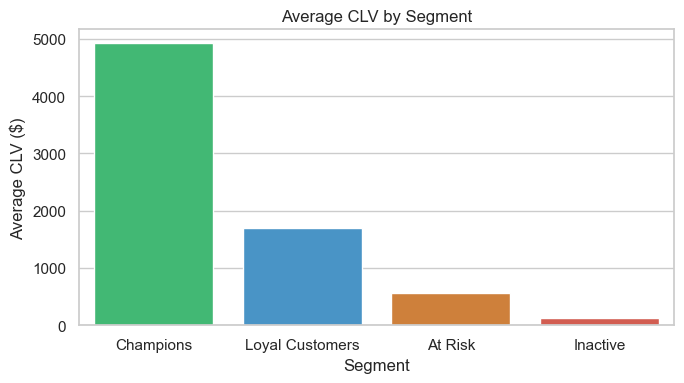

In [5]:
clv_by_segment = df.groupby('Segment')['CLV_Enhanced'].agg(['mean','sum','count'])
clv_by_segment.columns = ['Avg CLV','Total CLV','Customers']
clv_by_segment = clv_by_segment.sort_values('Avg CLV', ascending=False)

print("CLV by Segment:")
print(clv_by_segment.round(2))

plt.figure(figsize=(7,4))
sns.barplot(x=clv_by_segment.index, y=clv_by_segment['Avg CLV'], 
            palette=['#2ecc71','#3498db','#e67e22','#e74c3c'])
plt.title('Average CLV by Segment')
plt.xlabel('Segment')
plt.ylabel('Average CLV ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
top_customers = df.nlargest(20, 'CLV_Enhanced')[
    ['customerID','tenure','MonthlyCharges','TotalCharges',
     'Segment','CLV_Enhanced','CLV_Tier','Churn']
]

print("Top 20 Most Valuable Customers:")
print(top_customers.to_string(index=False))

Top 20 Most Valuable Customers:
customerID  tenure  MonthlyCharges  TotalCharges   Segment  CLV_Enhanced CLV_Tier Churn
2889-FPWRM      72          117.80       8684.80 Champions       8684.80  Premium   Yes
7569-NMZYQ      72          118.75       8672.45 Champions       8672.45  Premium    No
9739-JLPQJ      72          117.50       8670.10 Champions       8670.10  Premium    No
9788-HNGUT      72          116.95       8594.40 Champions       8594.40  Premium    No
8879-XUAHX      71          116.25       8564.75 Champions       8564.75  Premium    No
9924-JPRMC      72          118.20       8547.15 Champions       8547.15  Premium    No
0675-NCDYU      72          116.40       8543.25 Champions       8543.25  Premium    No
6650-BWFRT      72          117.15       8529.50 Champions       8529.50  Premium    No
0164-APGRB      72          114.90       8496.70 Champions       8496.70  Premium    No
1488-PBLJN      72          116.85       8477.70 Champions       8477.70  Premium    No


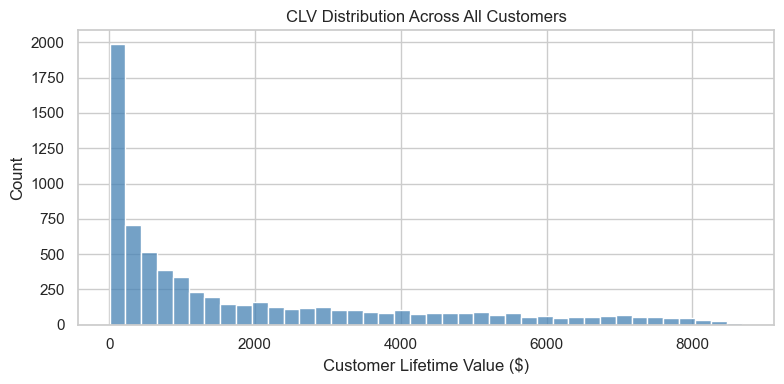

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(df['CLV_Enhanced'], bins=40, color='steelblue', edgecolor='white')
plt.title('CLV Distribution Across All Customers')
plt.xlabel('Customer Lifetime Value ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Churn Rate by CLV Tier (%):
CLV_Tier
Low Value       40.56
Medium Value    25.65
High Value      25.03
Premium         15.07
Name: Churn, dtype: float64


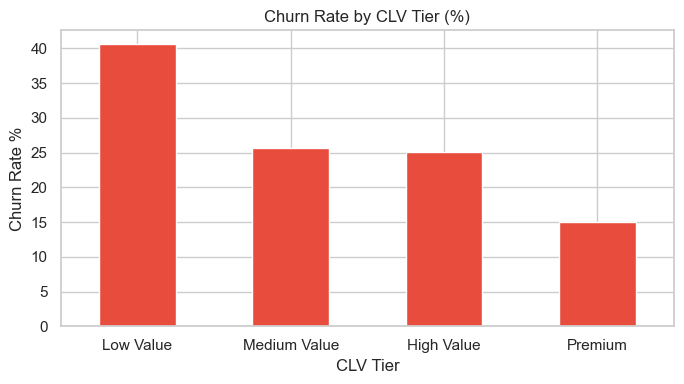

In [8]:
# Load full cleaned data to get Churn column
df_full = pd.read_csv('../data/telco_churn_cleaned.csv')
df['Churn'] = df['Churn']

churn_by_clv = df.groupby('CLV_Tier', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)

print("Churn Rate by CLV Tier (%):")
print(churn_by_clv)

plt.figure(figsize=(7,4))
churn_by_clv.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Churn Rate by CLV Tier (%)')
plt.xlabel('CLV Tier')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
clv_output = df[['customerID','tenure','MonthlyCharges','TotalCharges',
                  'RFM_Score','Segment','CLV_Enhanced','CLV_Tier','Churn']]

clv_output.to_csv('../outputs/clv_scores.csv', index=False)
print("CLV scores saved to ../outputs/clv_scores.csv")
print(f"Shape: {clv_output.shape}")
clv_output.head()

CLV scores saved to ../outputs/clv_scores.csv
Shape: (7032, 9)


,customerID,tenure,MonthlyCharges,TotalCharges,RFM_Score,Segment,CLV_Enhanced,CLV_Tier,Churn
0,7590-VHVEG,1,29.85,29.85,3,Inactive,7.46,Low Value,No
1,5575-GNVDE,34,56.95,1889.50,7,At Risk,1102.21,High Value,No
2,3668-QPYBK,2,53.85,108.15,5,Inactive,45.06,Low Value,Yes
3,7795-CFOCW,45,42.30,1840.75,7,At Risk,1073.77,High Value,No
4,9237-HQITU,2,70.70,151.65,5,Inactive,63.19,Low Value,Yes


## CLV Summary

| CLV Tier | Avg CLV | Business Priority |
|---|---|---|
| Premium | Highest | Protect at all costs |
| High Value | High | Proactive retention |
| Medium Value | Medium | Standard retention offers |
| Low Value | Low | Low-cost email campaigns |

**Key Insight:** Premium CLV customers who are also At Risk segment = highest priority for retention intervention in Module 3.